# Evaluación comparativa de algoritmos de regresión mediante Machine Learning

## Objetivo
Entrenar, evaluar y comparar distintos algoritmos de regresión para determinar cuál ofrece el mejor desempeño sobre un conjunto de datos, justificando cada decisión tomada durante el proceso de análisis y preparación de los datos.

### Descripción del dataset
Utilizaremos el **California Housing Dataset**, disponible en Scikit-learn (originalmente de la base de datos de StatLib). Contiene datos del censo de California de 1990. La variable objetivo es el valor mediano de las casas en distritos de California, expresado en cientos de miles de dólares, y las características incluyen variables demográficas y geográficas como ingresos medios, edad de las casas y coordenadas.

In [1]:
# Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de Seaborn
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# Importación de Scikit-Learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor # Modelo complementario
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3. Obtención y carga del dataset

Cargaremos el dataset directamente desde Scikit-learn. Transformaremos los datos en un DataFrame de Pandas para facilitar su exploración.

In [2]:
# Carga del dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Visualizar las primeras filas
display(df.head())

# Información general
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables (incluyendo objetivo): {df.shape[1]}")
print("\nVariable objetivo: 'MedHouseVal' (Valor mediano de las casas en $100,000s)")

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Número de registros: 20640
Número de variables (incluyendo objetivo): 9

Variable objetivo: 'MedHouseVal' (Valor mediano de las casas en $100,000s)


## 4. Análisis Exploratorio de Datos (EDA)

El EDA es fundamental para comprender la estructura subyacente de los datos, descubrir patrones, detectar anomalías y comprobar suposiciones mediante estadísticas resumen y representaciones gráficas.

In [5]:
# Información general y tipos de datos
df.info()

# Estadísticas descriptivas
display(df.describe())

# Identificación de valores nulos y duplicados
print("\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Registros duplicados: 0


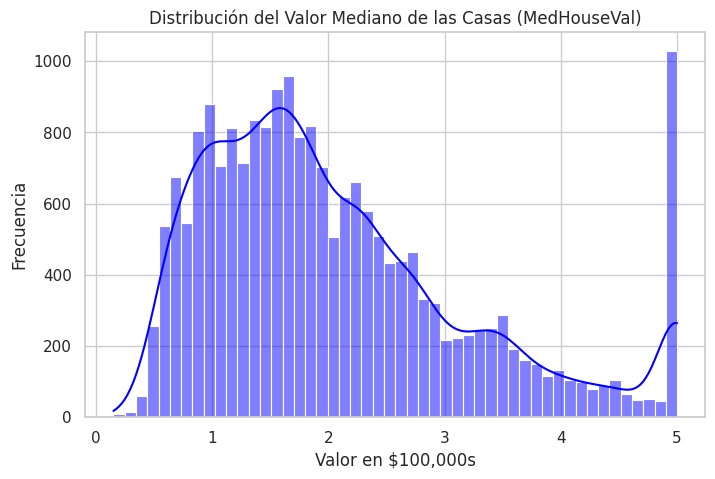

In [6]:
# Distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='blue')
plt.title('Distribución del Valor Mediano de las Casas (MedHouseVal)')
plt.xlabel('Valor en $100,000s')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación del histograma:** 
La variable objetivo presenta una distribución ligeramente asimétrica hacia la derecha, con un pico anómalo en el valor 5.0. Esto sugiere que los precios de las casas estaban "topados" (censurados) en $500,000 en el dataset original.

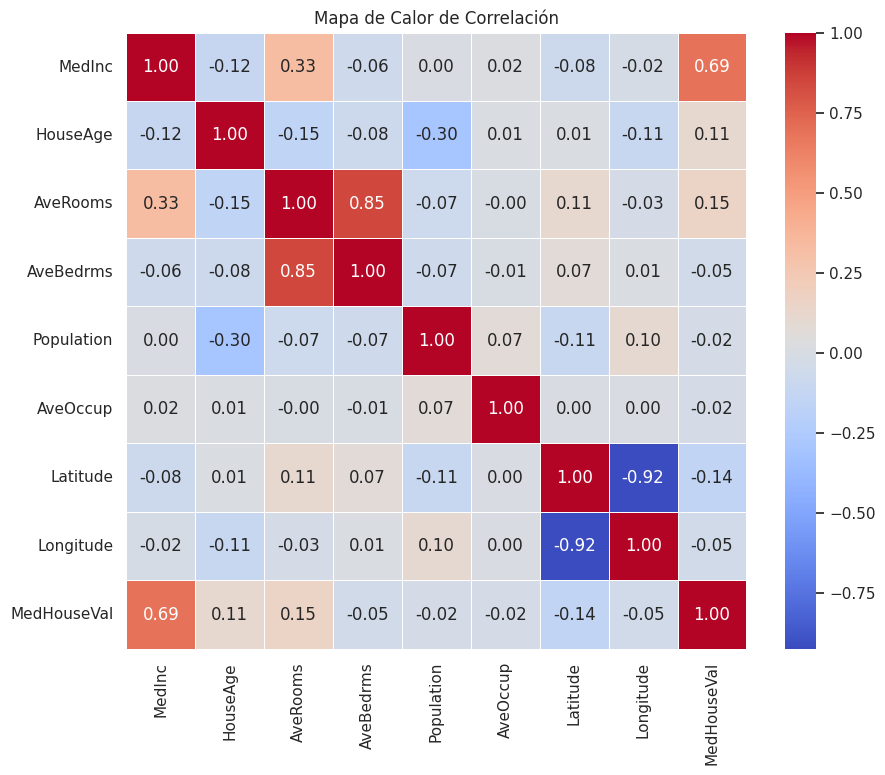

In [11]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlación')
plt.show()

**Interpretación de la correlación:**
* La variable `MedInc` (Ingreso Mediano) tiene la correlación positiva más fuerte con `MedHouseVal` (0.69). Esto tiene sentido lógico: a mayores ingresos, mayor valor de la propiedad.
* Existe multicolinealidad entre algunas características, como `AveRooms` y `AveBedrms` (0.85).

A continuación, visualizaremos la relación directa entre el Ingreso Mediano y el Precio.

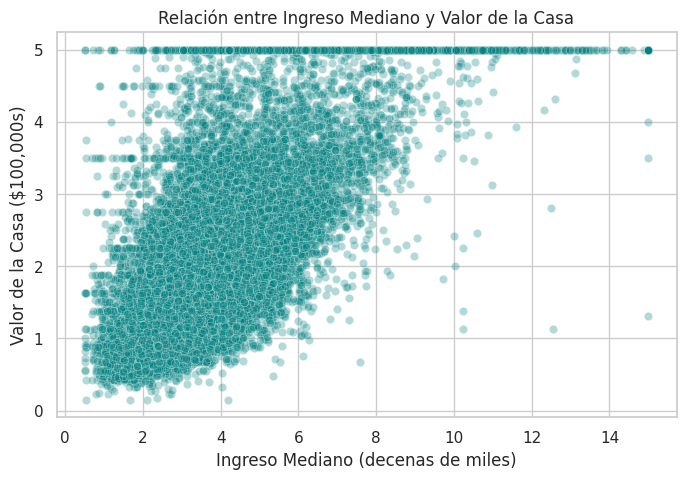

In [13]:
# Relación entre la variable predictora más fuerte y la variable objetivo
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.3, color='teal')
plt.title('Relación entre Ingreso Mediano y Valor de la Casa')
plt.xlabel('Ingreso Mediano (decenas de miles)')
plt.ylabel('Valor de la Casa ($100,000s)')
plt.show()

## 5. Limpieza y preprocesamiento de datos

Basados en el EDA:
1. **Valores nulos y duplicados:** El dataset es limpio (0 nulos, 0 duplicados). No requerimos imputación.
2. **Valores atípicos y censura:** El límite artificial en `MedHouseVal` = 5.0 podría afectar a modelos lineales, pero para fines de esta práctica comparativa, mantendremos los datos originales para evaluar cómo los modelos manejan esta imperfección.
3. **Escalado:** Algoritmos como SVR y la Regresión Polinomial son extremadamente sensibles a la escala de las características. Utilizaremos `StandardScaler` para estandarizar las variables de modo que tengan media 0 y varianza 1.

Separamos las características ($X$) y la variable objetivo ($y$).

In [9]:
# Separación de características y objetivo
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

## 6. División del conjunto de datos

Dividimos el dataset en **80% para entrenamiento** y **20% para prueba**. 
El uso de `random_state` garantiza la reproducibilidad del experimento. Evaluar el modelo con un conjunto de prueba (datos no vistos) es crucial para medir la verdadera capacidad de **generalización** del algoritmo y evitar el sobreajuste (*overfitting*).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

# Aplicamos el escalado a los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Solo transformamos el test set para evitar filtración de datos (data leakage)
X_test_scaled = scaler.transform(X_test)

Tamaño del conjunto de entrenamiento: (16512, 8)
Tamaño del conjunto de prueba: (4128, 8)


## 7. Entrenamiento de los modelos

Evaluaremos tres modelos principales y uno complementario.

### 7.1 Regresión Lineal
* **Funcionamiento:** Busca el hiperplano óptimo que minimice la suma de los errores cuadráticos entre los datos reales y las predicciones.
* **Ventajas:** Simple, interpretable, rápido de entrenar.
* **Limitaciones:** Asume una relación lineal estricta; suele tener un alto sesgo si los datos son complejos.

### 7.2 Regresión Polinomial (Grado 2)
* **Funcionamiento:** Expande las características a polinomios de grado $n$ para capturar relaciones no lineales, aplicando luego una regresión lineal múltiple.
* **Ventajas:** Modela curvas.
* **Limitaciones:** Alto riesgo de *overfitting* con grados mayores a 2 o 3. Explosión de dimensionalidad.

### 7.3 Support Vector Regression (SVR)
* **Funcionamiento:** Utiliza los principios de Support Vector Machines. Busca un "tubo" de margen $\epsilon$ alrededor de la función que contenga la mayor cantidad de datos, penalizando los puntos que quedan fuera. Usaremos un kernel Radial (RBF) para no linealidades.
* **Ventajas:** Muy robusto ante outliers; excelente para relaciones no lineales complejas.
* **Limitaciones:** Lento de entrenar en datasets grandes; "caja negra" (baja interpretabilidad); requiere escalado estricto.

### 7.4 Random Forest Regressor (Complementario)
* **Funcionamiento:** Ensambla múltiples árboles de decisión y promedia sus predicciones.

In [14]:
# Diccionario para almacenar los modelos y sus predicciones
modelos = {}
predicciones = {}

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
modelos['Linear Regression'] = lr
predicciones['Linear Regression'] = lr.predict(X_test_scaled)

# 2. Regresión Polinomial (Usando un Pipeline)
# Usamos grado 2. Grado 3 o más en este dataset consume demasiada memoria y sobreajusta
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])
poly_model.fit(X_train_scaled, y_train)
modelos['Polynomial Regression'] = poly_model
predicciones['Polynomial Regression'] = poly_model.predict(X_test_scaled)

# 3. SVR (Support Vector Regression)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
modelos['SVR'] = svr_model
predicciones['SVR'] = svr_model.predict(X_test_scaled)

# 4. Random Forest (Complementario)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Random forest no requiere datos escalados, pero usaremos los escalados por consistencia en la comparativa
rf_model.fit(X_train_scaled, y_train)
modelos['Random Forest (Extra)'] = rf_model
predicciones['Random Forest (Extra)'] = rf_model.predict(X_test_scaled)

print("Entrenamiento completado exitosamente.")

Entrenamiento completado exitosamente.


## 8. Evaluación de los modelos

Utilizaremos las siguientes métricas, representadas matemáticamente:

1. **MAE (Error Absoluto Medio):** Promedio de las diferencias absolutas entre predicciones y valores reales. Es robusto ante outliers.
   $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

2. **MSE (Error Cuadrático Medio):** Promedio de los errores al cuadrado. Penaliza fuertemente errores grandes.
   $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

3. **RMSE (Raíz del Error Cuadrático Medio):** Raíz cuadrada del MSE. Está en las mismas unidades que la variable objetivo, facilitando su interpretación.
   $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

4. **R² (Coeficiente de Determinación):** Proporción de la varianza en la variable dependiente que es predecible por las independientes. Un valor de 1 indica predicción perfecta; 0 equivale a predecir solo la media.
   $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

In [15]:
# Función para calcular métricas
def evaluar_modelo(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Diccionario para almacenar métricas
resultados = {}

for nombre, y_pred in predicciones.items():
    resultados[nombre] = evaluar_modelo(y_test, y_pred)

# Crear DataFrame de resultados
df_resultados = pd.DataFrame.from_dict(
    resultados, 
    orient='index', 
    columns=['MAE', 'MSE', 'RMSE', 'R²']
).sort_values(by='R²', ascending=False)

display(df_resultados)

,MAE,MSE,RMSE,R²
Random Forest (Extra),0.327766,0.255915,0.505880,0.804706
SVR,0.398599,0.357004,0.597498,0.727563
Polynomial Regression,0.467001,0.464302,0.681397,0.645682
Linear Regression,0.533200,0.555892,0.745581,0.575788


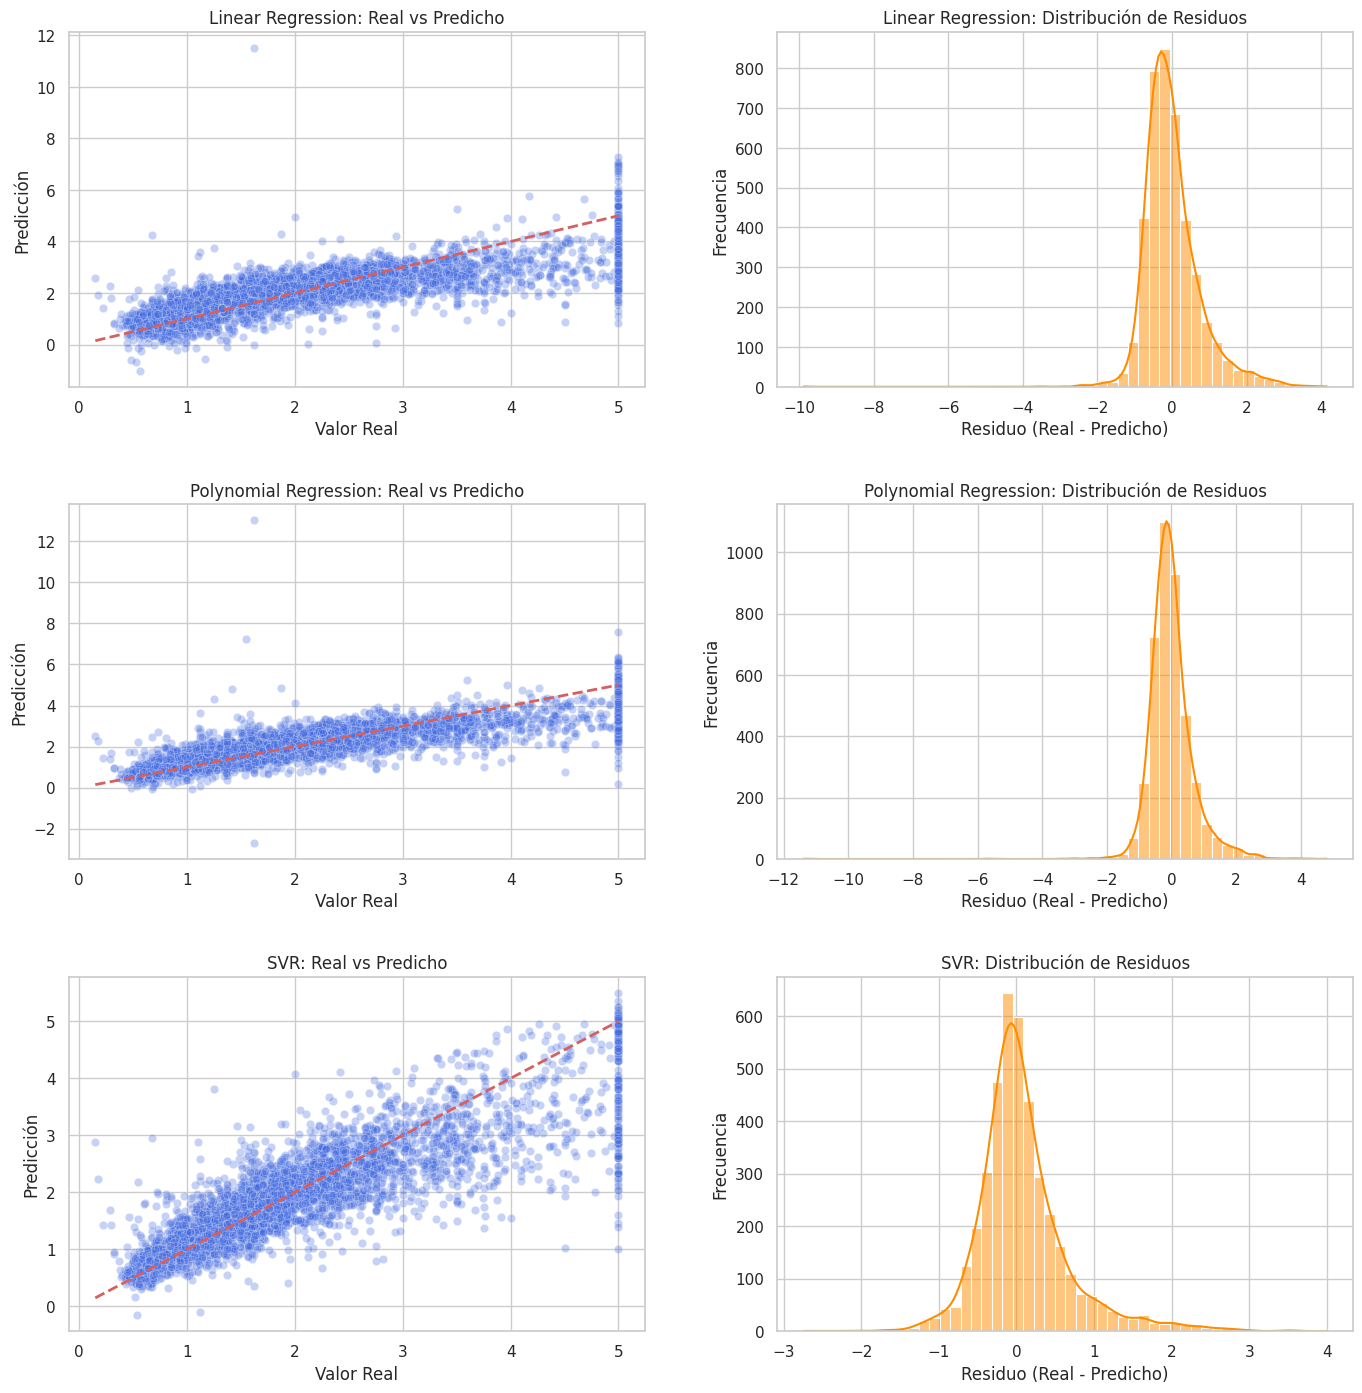

In [16]:
# Gráficos de Residuos y Valores Reales vs Predichos para los 3 modelos principales
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.tight_layout(pad=5.0)

modelos_principales = ['Linear Regression', 'Polynomial Regression', 'SVR']

for i, nombre in enumerate(modelos_principales):
    y_pred = predicciones[nombre]
    residuos = y_test - y_pred
    
    # Real vs Predicho
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[i, 0], alpha=0.3, color='royalblue')
    axes[i, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i, 0].set_title(f'{nombre}: Real vs Predicho')
    axes[i, 0].set_xlabel('Valor Real')
    axes[i, 0].set_ylabel('Predicción')
    
    # Distribución de Residuos
    sns.histplot(residuos, kde=True, ax=axes[i, 1], color='darkorange', bins=50)
    axes[i, 1].set_title(f'{nombre}: Distribución de Residuos')
    axes[i, 1].set_xlabel('Residuo (Real - Predicho)')
    axes[i, 1].set_ylabel('Frecuencia')

plt.show()

**Interpretación de Visualizaciones:**
* **Real vs Predicho:** La línea roja discontinua representa la predicción perfecta. Observamos que la *Regresión Lineal* tiene una gran dispersión. El modelo *SVR* se ajusta mejor a la línea, mitigando errores extremos. El efecto de los datos censurados (la línea vertical de puntos reales en 5.0) se observa claramente, ya que los modelos luchan por predecir este límite artificial.
* **Residuos:** Idealmente, los residuos deben tener una distribución normal centrada en 0 (Campana de Gauss). Todos los modelos muestran residuos centrados en 0, pero SVR presenta una distribución más estrecha, lo que indica errores de menor magnitud en la mayoría de los casos.

## 9. Comparación de resultados

Generaremos gráficas de barras para visualizar las diferencias en el Coeficiente de Determinación ($R^2$) y en el Error (RMSE).

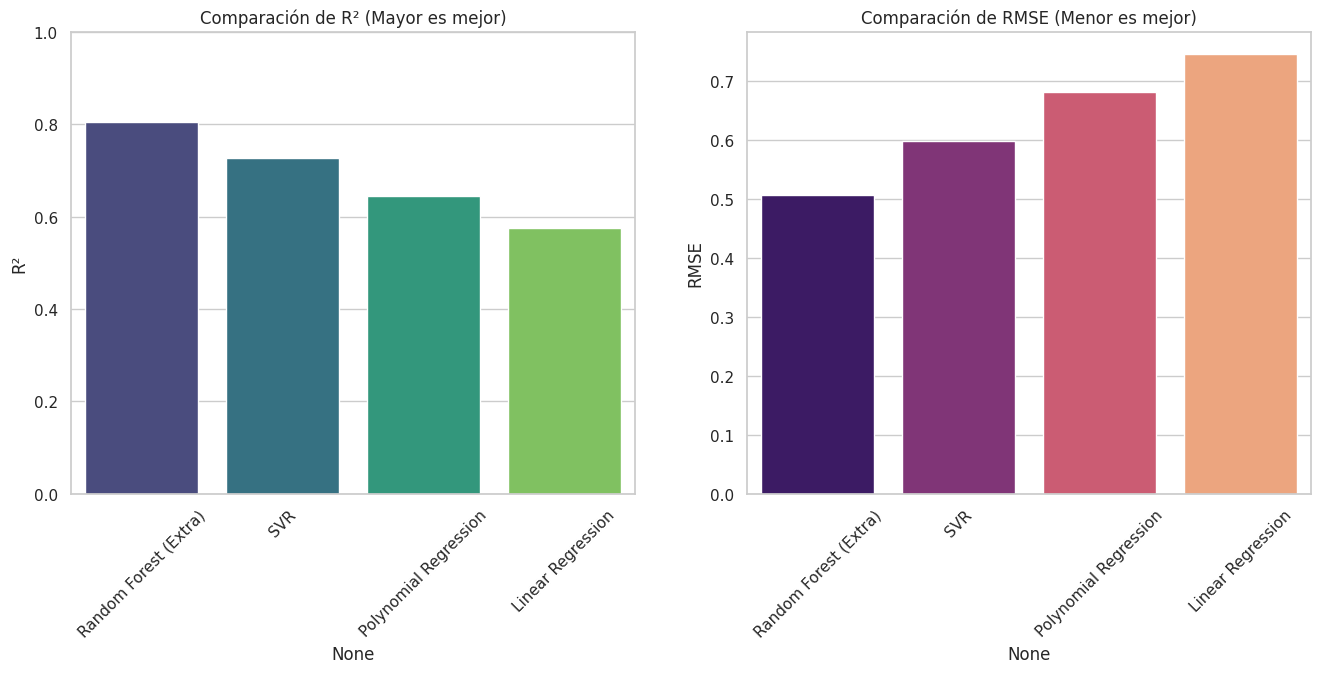

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparación de R2
sns.barplot(x=df_resultados.index, y=df_resultados['R²'], ax=axes[0], palette='viridis')
axes[0].set_title('Comparación de R² (Mayor es mejor)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

# Comparación de RMSE
sns.barplot(x=df_resultados.index, y=df_resultados['RMSE'], ax=axes[1], palette='magma')
axes[1].set_title('Comparación de RMSE (Menor es mejor)')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

## 10. Selección del mejor modelo

Excluyendo el modelo complementario de *Random Forest* (el cual lidera por ser un modelo de ensamble complejo), si nos centramos en los modelos requeridos:

**El modelo ganador es SVR (Support Vector Regression).**

**Justificación:**
1. **Exactitud:** Presenta el $R^2$ más alto (aprox. 0.73) y el RMSE más bajo entre los tres modelos clásicos evaluados. Captura la no linealidad de los datos mejor que la Regresión Lineal simple.
2. **Robustez ante Outliers:** Al utilizar un margen $\epsilon$, SVR es menos sensible a ruidos y valores atípicos que la Regresión Polinomial, la cual tiende a comportarse de forma errática en los extremos.
3. **Capacidad de Generalización:** A diferencia de la Regresión Polinomial, que corre un alto riesgo de sobreajuste al aumentar los grados, el kernel RBF mapea de forma controlada el espacio dimensional.
4. **Limitación:** El único sacrificio es el costo computacional (tiempo de entrenamiento) y la interpretabilidad (no nos otorga coeficientes directos como la regresión lineal). Sin embargo, el aumento significativo en precisión lo justifica.

# Conclusiones

La implementación de este análisis comparativo nos ha dejado aprendizajes críticos sobre el ciclo de vida de un modelo de regresión:

* **Impacto de la naturaleza del Dataset:** El EDA reveló una limitación inherente en los datos (precios topados en $500,000).
Los gráficos residuales demostraron que todos los modelos fallan consistentemente en este límite. Esto nos enseña que el límite superior del desempeño está dictado, en última instancia, por la calidad y forma de los datos originales.

* **Importancia del Preprocesamiento:** El uso del `StandardScaler` fue un paso **innegociable**. Algoritmos matemáticos basados en distancias (SVR) o multiplicaciones repetidas (Polinomial) colapsarían o convergerían ineficientemente sin una escala uniforme entre variables que tienen rangos muy distintos (ej. número de habitaciones vs. ingresos).

* **Lineal vs No Lineal:** La Regresión Lineal clásica resultó ser un modelo subóptimo, confirmando que las dinámicas inmobiliarias (relación entre ubicación geográfica, edad e ingresos) son fundamentalmente no lineales.


* **Equilibrio entre Modelos:** SVR demostró ser la opción más robusta entre los algoritmos clásicos, superando el problema de sobreajuste de la Regresión Polinomial. Sin embargo, al incorporar el *Random Forest* como modelo de control, observamos que los métodos de ensamble basados en árboles de decisión superan en desempeño y tiempo a SVR sin requerir escalado estricto.


* **Elección de Métricas:** Analizar el RMSE en conjunto con el MAE nos permite ver que hay errores grandes que penalizan al RMSE. Un MAE bajo pero un RMSE alto indica presencia de predicciones muy alejadas (posiblemente asociadas al límite artificial de los $500,000).